In [2]:
import json
from pathlib import Path

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

INFO: P [MainThread] 2025-10-28 21:07:01,829 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/transfer_results/consistency/transfer_performance_F1_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/transfer_results/consistency/NHD_consistency/FORG/transfer_Gauss_a0-005_Forg_NHD_scores.json
Processing: Gauss_Consistency_a0-005
Number of targets: 4
  Target 1: BBBC039
  Target 2: DSB2018
  Target 3: Hoechst
  Target 4: S_BIAD895


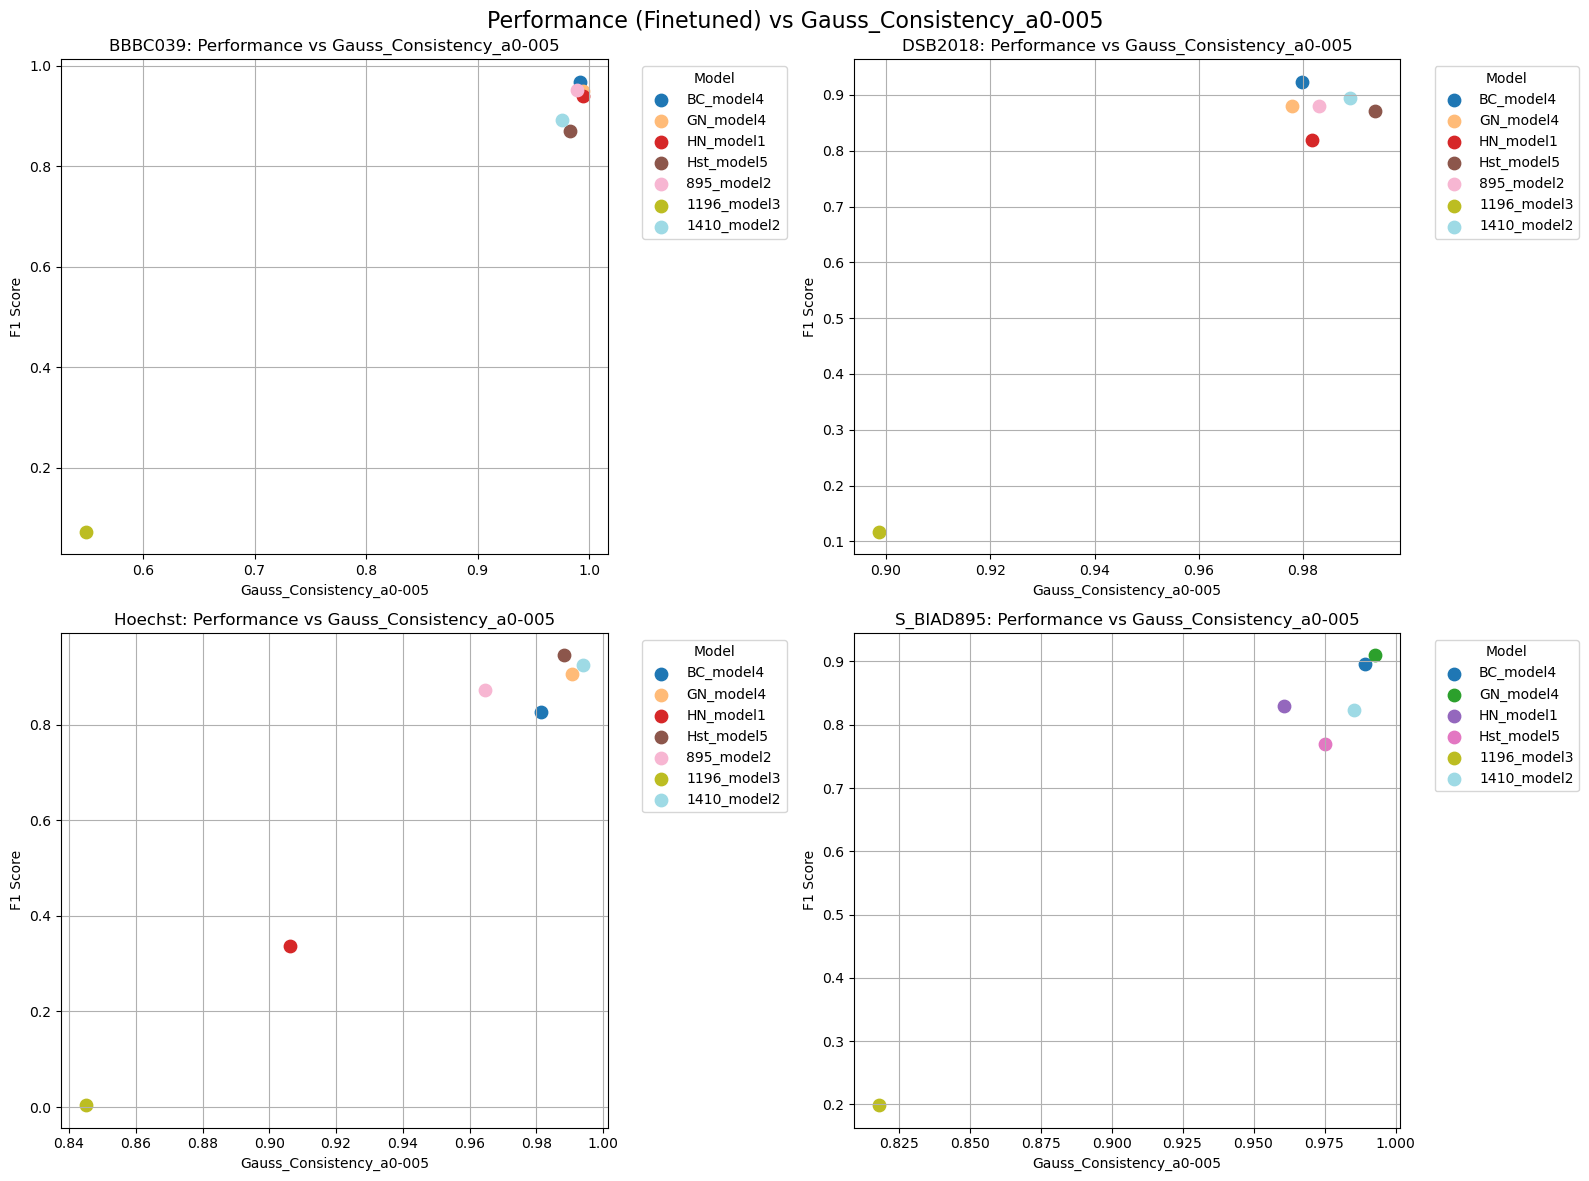

                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.43     0.28   0.64        0.11  1.00      0.0
     DSB2018    0.14     0.79   0.18        0.69  0.98      0.0
     Hoechst    0.71     0.03   0.86        0.03  0.99      0.0
     S_BIAD895  0.73     0.04   0.83        0.07  0.99      0.0
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/transfer_results/consistency/NHD_consistency/FORG/transfer_Gauss_a005-01_Forg_NHD_scores.json
Processing: Gauss_Consistency_a005-01
Number of targets: 4
  Target 1: BBBC039
  Target 2: DSB2018
  Target 3: Hoechst
  Target 4: S_BIAD895


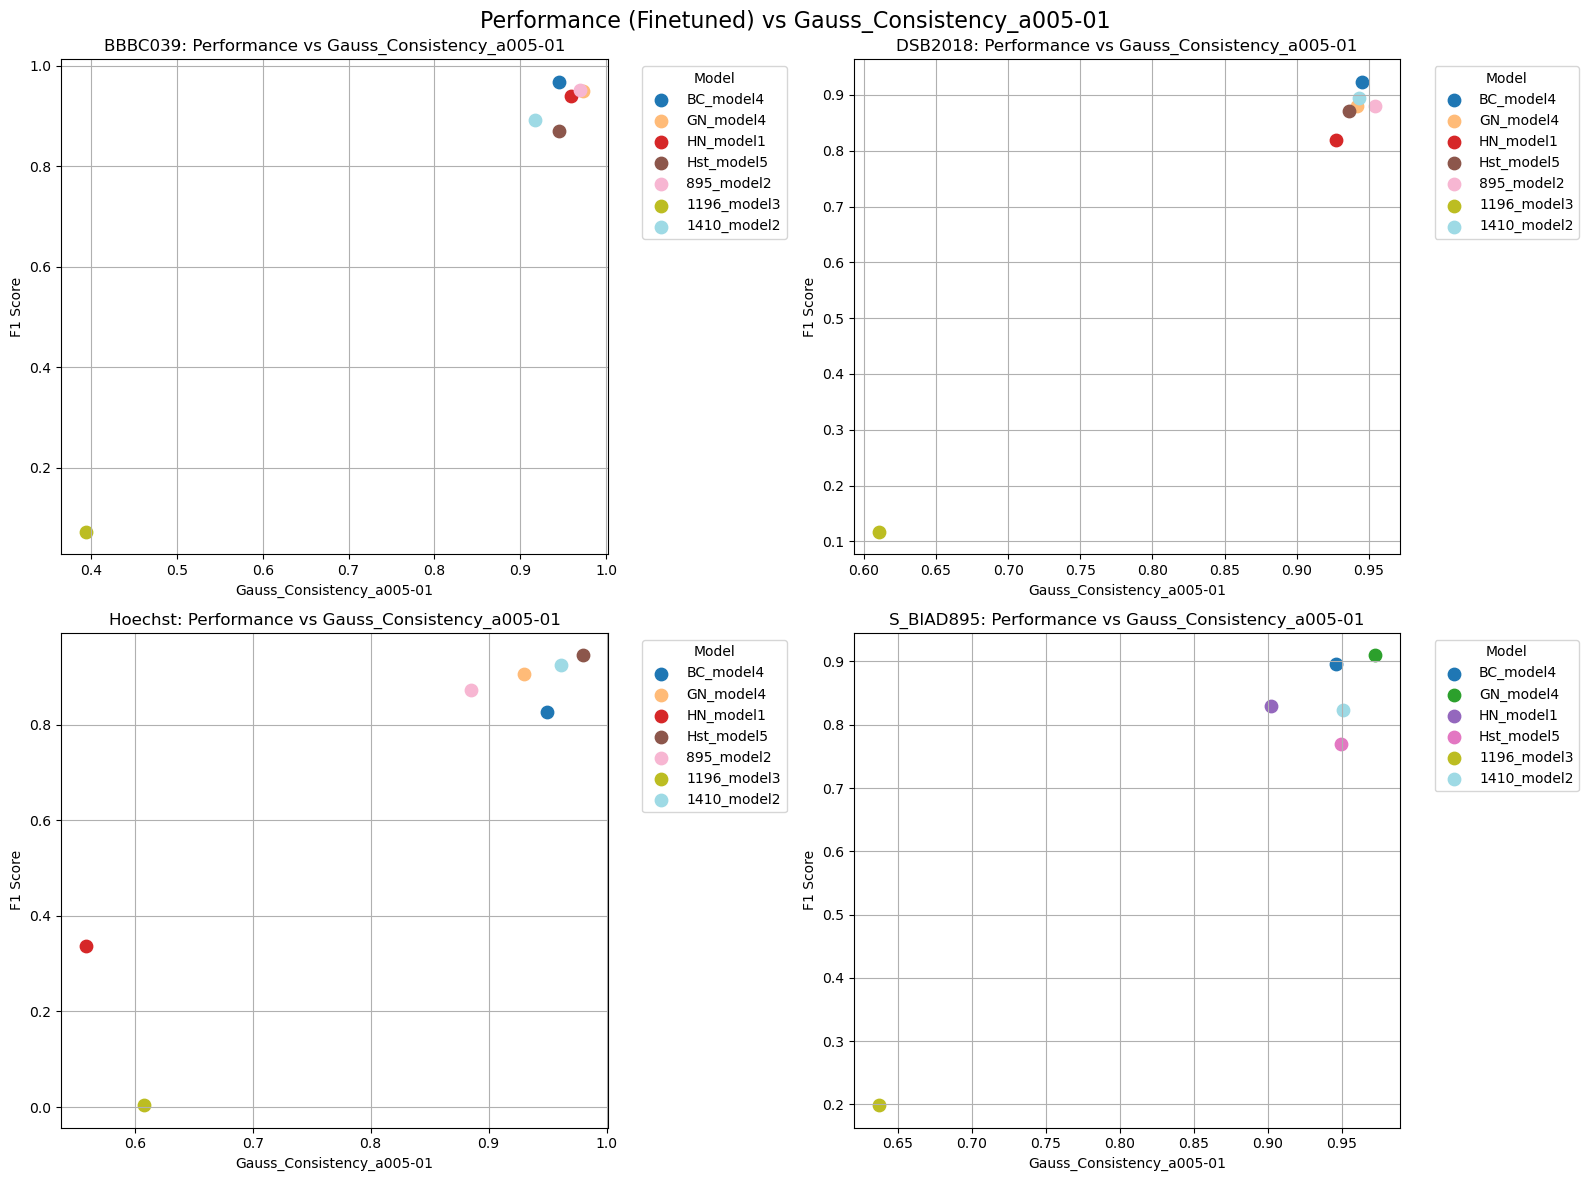

                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.52     0.16   0.71        0.09  1.00      0.0
     DSB2018    0.71     0.03   0.79        0.04  1.00      0.0
     Hoechst    0.71     0.03   0.86        0.02  0.93      0.0
     S_BIAD895  0.47     0.28   0.54        0.32  0.98      0.0
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/transfer_results/consistency/NHD_consistency/FORG/transfer_Gauss_a01-02_Forg_NHD_scores.json
Processing: Gauss_Consistency_a01-02
Number of targets: 4
  Target 1: BBBC039
  Target 2: DSB2018
  Target 3: Hoechst
  Target 4: S_BIAD895


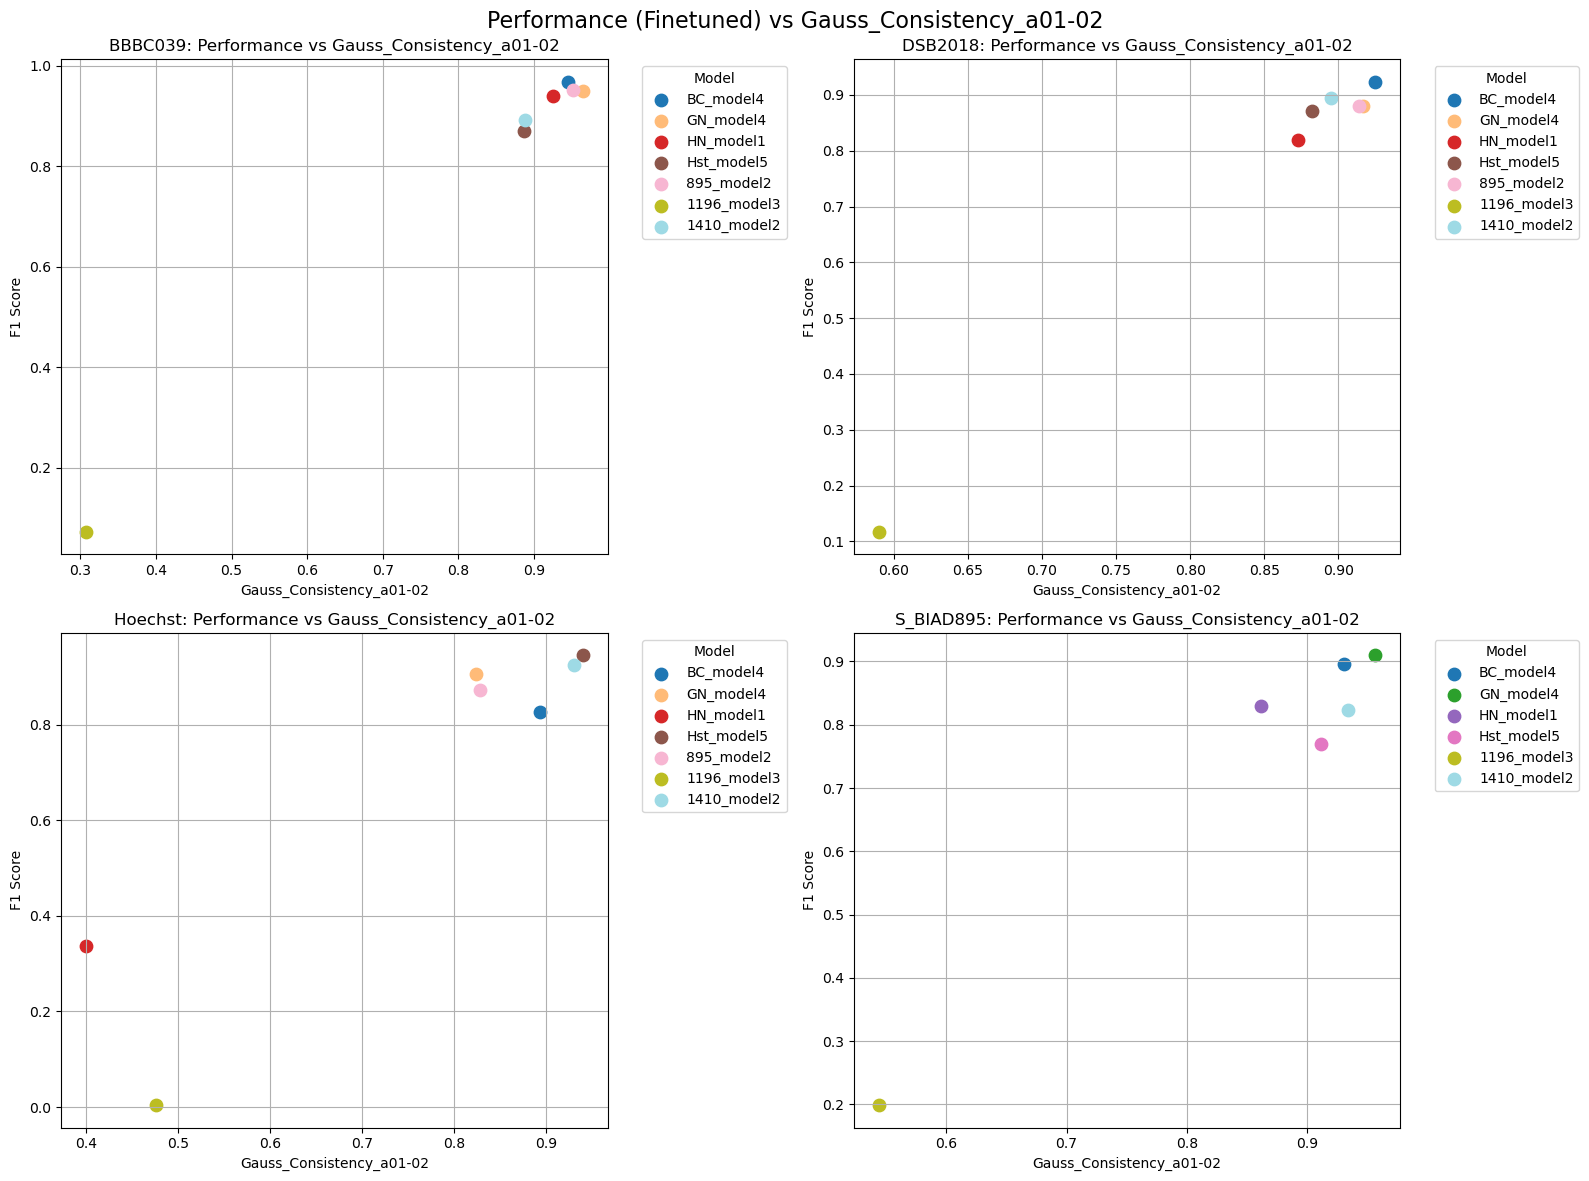

                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.71     0.02   0.86        0.03  1.00      0.0
     DSB2018    0.81     0.02   0.89        0.02  1.00      0.0
     Hoechst    0.62     0.06   0.82        0.03  0.92      0.0
     S_BIAD895  0.60     0.16   0.71        0.12  0.98      0.0


In [5]:
base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/transfer_results/consistency/NHD_consistency/FORG"
selected_augmentations = ["a0-005", "a005-01", "a01-02"]

for aug in selected_augmentations:
    file_name = f"transfer_Gauss_{aug}_Forg_NHD_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
        transfer_scores=consistency_scores,
        transfer_metric=f"Gauss_Consistency_{aug}",
        finetuned=True,
        invert_transfer_metric=True,
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
        )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        